In [1]:
#import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#load and read dataset
df=pd.read_csv("/content/Housing.csv")



In [2]:
#display first 5 rows
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
#display last 5 rows
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [4]:
#display shape of dataset
df.shape

(545, 13)

In [5]:
#check null values
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [6]:
#check duplicate columns
df.duplicated().sum()

np.int64(0)

In [7]:
#statistical analysis
df.describe()


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [9]:
#handling categorical data (encoding)
binary_cols=['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
for cols in binary_cols:
  df[cols]=df[cols].map({'yes':1,'no':0})

In [10]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [11]:
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

In [12]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [13]:
print(df['furnishingstatus_semi-furnished'].unique())
print(df['furnishingstatus_unfurnished'].unique())

[False  True]
[False  True]


In [14]:
binary_cols=['furnishingstatus_semi-furnished','furnishingstatus_unfurnished']
for cols in binary_cols:
  df[cols]=df[cols].map({True:1,False:0})

In [15]:
#'price'is the target variable (continuous)
X=df.drop("price",axis=1) #independent variable
y=df["price"] #dependent variable


In [16]:
#Train-Test Split
#splitting data into training and testing sets(80% training ,20% testing )
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
#Feature Scalling()
#Scalling is applied after splitting to avoid data leakage
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
#fit only on training data and transform both
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [18]:
#Train Model
#Linear Regression
from sklearn.linear_model import LinearRegression
lr= LinearRegression()
lr.fit(X_train,y_train)
y_pred_lr = lr.predict(X_test)

In [19]:
#  Decision Tree Regression
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(X_train,y_train)
y_pred_dt =dt.predict(X_test)


In [20]:
#Random Forest Regression
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(X_train,y_train)
y_pred_rf =rf.predict(X_test)

In [21]:
#Model Evaluation
#Import evaluation metrics
from sklearn.metrics import mean_squared_error,r2_score
#Function to evaluate models
def evaluate_model(y_test,y_pred,model_name):
  print(f"\nModel :{model_name}")
  print("Mean Squared Error(MSE):",mean_squared_error(y_test,y_pred))
  print("R -squared (R2 Score):",r2_score(y_test, y_pred))


In [22]:
#Evaluate all models
evaluate_model(y_test,y_pred_lr,"Linear Regression")
evaluate_model(y_test,y_pred_dt,"Decision Tree Regression")
evaluate_model(y_test,y_pred_rf,"Random Forest")


Model :Linear Regression
Mean Squared Error(MSE): 1754318687330.668
R -squared (R2 Score): 0.6529242642153176

Model :Decision Tree Regression
Mean Squared Error(MSE): 2829466339449.5415
R -squared (R2 Score): 0.4402162396521636

Model :Random Forest
Mean Squared Error(MSE): 1983378958128.165
R -squared (R2 Score): 0.6076068070165647


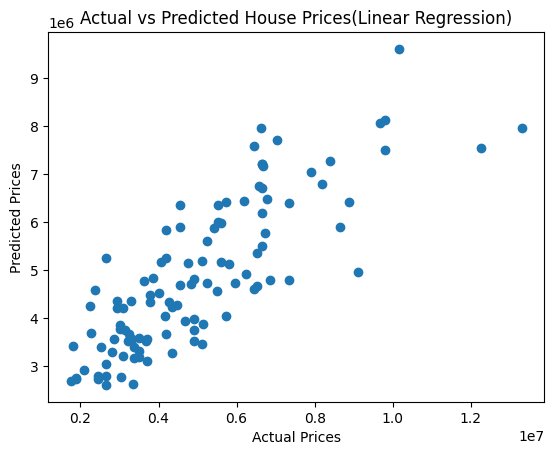

In [23]:
#Visualization
#plot Actual vs Predicted values (Linear Regression example)
plt.scatter(y_test,y_pred_lr)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices(Linear Regression)")
plt.show()

In [24]:
#The objective of this task is to predict house prices using regression models.
#The dataset contains various features such as area, bedrooms, bathrooms, and other house-related attributes.
#The target variable is price, which is continuous in nature.
#Categorical features were converted into numerical form using one-hot encoding.
#Feature scaling was applied using StandardScaler to normalize the data.
#The dataset was split into training (80%) and testing (20%) sets.
#Three models were used: Linear Regression, Decision Tree, and Random Forest.
#Model performance was evaluated using Mean Squared Error (MSE) and R² score.
#Random Forest performed better compared to other models.
#Therefore, Random Forest is the most suitable model for predicting house prices.